## EDA 

In [10]:
# EDA for assessments dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cell 2: Load Data
try:
    assessments = pd.read_csv('../dataset/assessments.csv')
    student_assessments = pd.read_csv('../dataset/studentAssessment.csv')
    student_vle = pd.read_csv('../dataset/studentVle.csv') 
    
    print("✅ Datasets Loaded")
    print(f"Assessments shape: {assessments.shape}")
    print(f"Student Submissions shape: {student_assessments.shape}")
    print(f"Student Interactions shape: {student_vle.shape}")

except FileNotFoundError:
    print("❌ Error: Files not found. Please upload 'assessments.csv', 'studentAssessment.csv', and 'studentVle.csv'.")

✅ Datasets Loaded
Assessments shape: (206, 6)
Student Submissions shape: (173912, 5)
Student Interactions shape: (10655280, 6)


--- Missing Values in assessments ---
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

--- Value Counts for Categorical Features ---

assessment_type:
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64

code_module:
code_module
FFF    52
BBB    42
DDD    35
GGG    30
CCC    20
EEE    15
AAA    12
Name: count, dtype: int64

code_presentation:
code_presentation
2014J    57
2014B    57
2013J    53
2013B    39
Name: count, dtype: int64


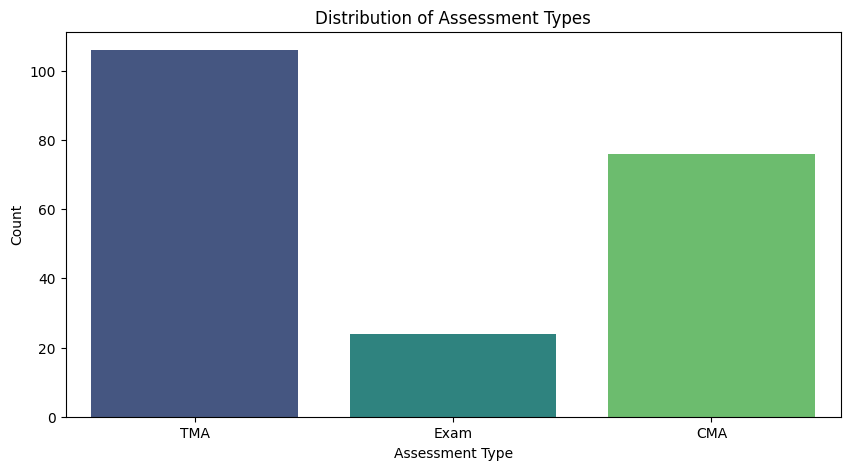

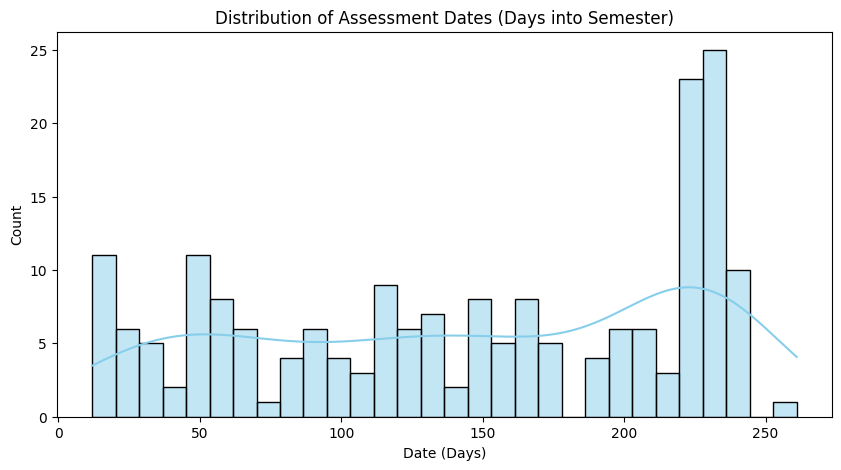

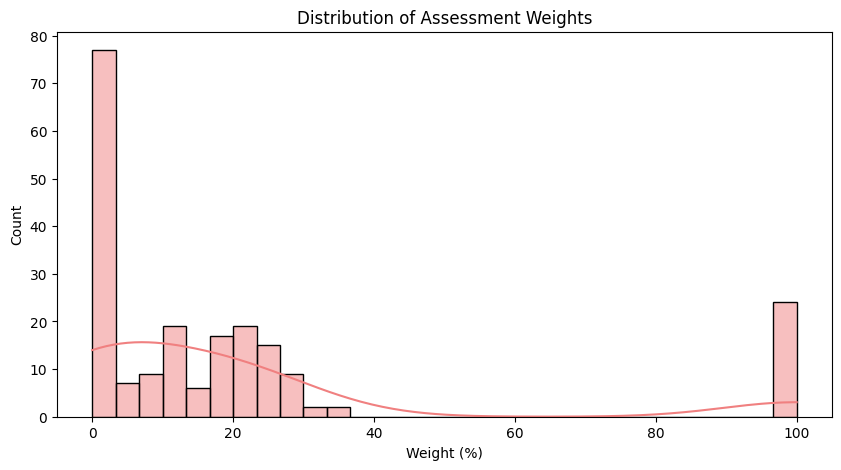

In [13]:
# EDA for assessments data
# assessment_type: Type of assessment. Three types of assessments exist: 
# Tutor Marked Assessment (TMA), Computer Marked Assessment (CMA) and Final Exam (Exam).

# date: Information about the final submission date of the assessment calculated as the number of days
# since the start of the module-presentation. The starting date of the presentation has number 0 (zero)

# weight: Weight of the assessment in %. Typically, Exams are treated separately and have the weight 100%; the sum of all other assessments is 100%.
print("--- Missing Values in assessments ---")
print(assessments.isnull().sum())

print("\n--- Value Counts for Categorical Features ---")
for col in ['assessment_type', 'code_module', 'code_presentation']:
    print(f"\n{col}:")
    print(assessments[col].value_counts())

# Visualize assessment types
plt.figure(figsize=(10, 5))
sns.countplot(data=assessments, x='assessment_type', hue='assessment_type', palette='viridis', legend=False)
plt.title('Distribution of Assessment Types')
plt.xlabel('Assessment Type')
plt.ylabel('Count')
plt.show()

# Visualize assessment dates
plt.figure(figsize=(10, 5))
sns.histplot(assessments['date'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Assessment Dates (Days into Semester)')
plt.xlabel('Date (Days)')
plt.ylabel('Count')
plt.show()

# Visualize assessment weights
plt.figure(figsize=(10, 5))
sns.histplot(assessments['weight'], bins=30, kde=True, color='lightcoral')
plt.title('Distribution of Assessment Weights')
plt.xlabel('Weight (%)')
plt.ylabel('Count')
plt.show()



--- Missing Values in student_assessments ---
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

--- Value Counts for 'is_banked' ---
is_banked
0    172003
1      1909
Name: count, dtype: int64


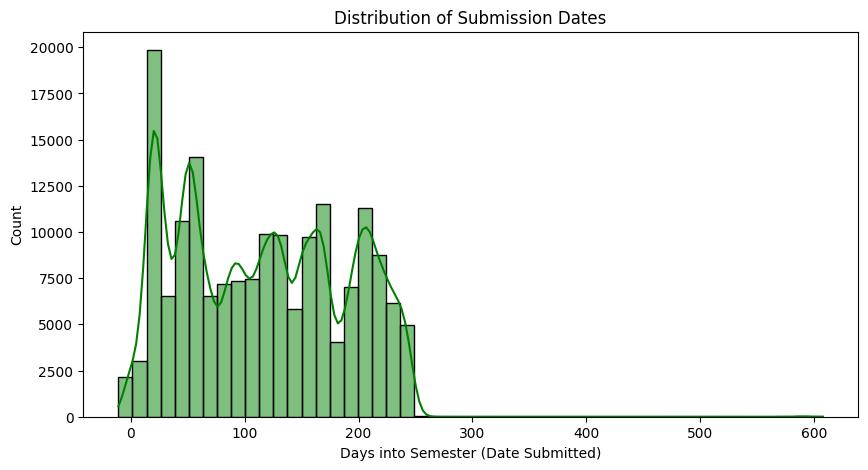

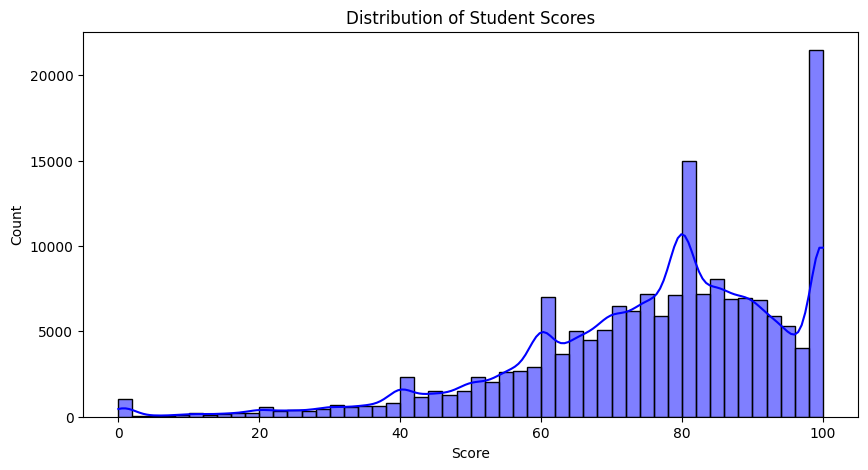

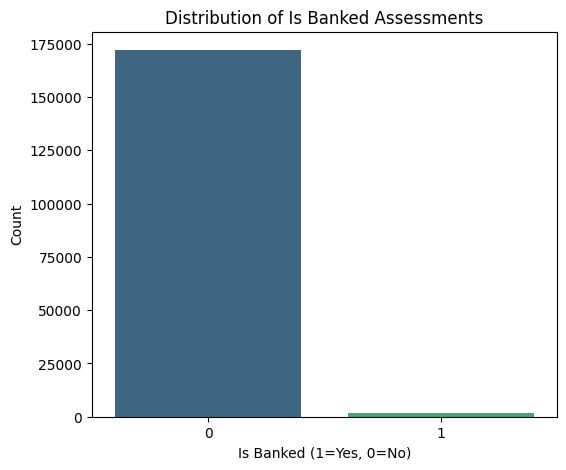

In [27]:
# EDA for student_assessments data
# date_submitted: The date of student submission, measured as the number of days since the start of the module presentation.
# is_banked : A status flag indicating that the assessment result has been transferred from a previous presentation.
#score: The student’s score in this assessment. The range is from 0 to 100. The score lower than 40 is interpreted as Fail. The marks are in the range from 0 to 100.

print("--- Missing Values in student_assessments ---")
print(student_assessments.isnull().sum())

print("\n--- Value Counts for 'is_banked' ---")
print(student_assessments['is_banked'].value_counts())



# Visualize distribution of submission dates
plt.figure(figsize=(10, 5))
sns.histplot(student_assessments['date_submitted'], bins=50, kde=True, color='green')
plt.title('Distribution of Submission Dates')
plt.xlabel('Days into Semester (Date Submitted)')
plt.ylabel('Count')
plt.show()

# Visualize distribution of scores
plt.figure(figsize=(10, 5))
sns.histplot(student_assessments['score'].dropna(), bins=50, kde=True, color='blue')
plt.title('Distribution of Student Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

# Visualize distribution of 'is_banked'
plt.figure(figsize=(6, 5))
sns.countplot(data=student_assessments, x='is_banked', hue='is_banked', palette='viridis', legend=False)
plt.title('Distribution of Is Banked Assessments')
plt.xlabel('Is Banked (1=Yes, 0=No)')
plt.ylabel('Count')
plt.show()






--- Missing Values in student_vle ---
code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64

--- Value Counts for Categorical Features ---

code_module:
code_module
FFF    4014499
DDD    2166486
BBB    1567564
CCC    1207827
EEE     961433
Name: count, dtype: int64

code_presentation:
code_presentation
2014J    3619452
2013J    2988784
2014B    2160176
2013B    1886868
Name: count, dtype: int64

--- Unique Students and VLE Resources ---
Number of unique students: 26074
Number of unique VLE resources (id_site): 6268


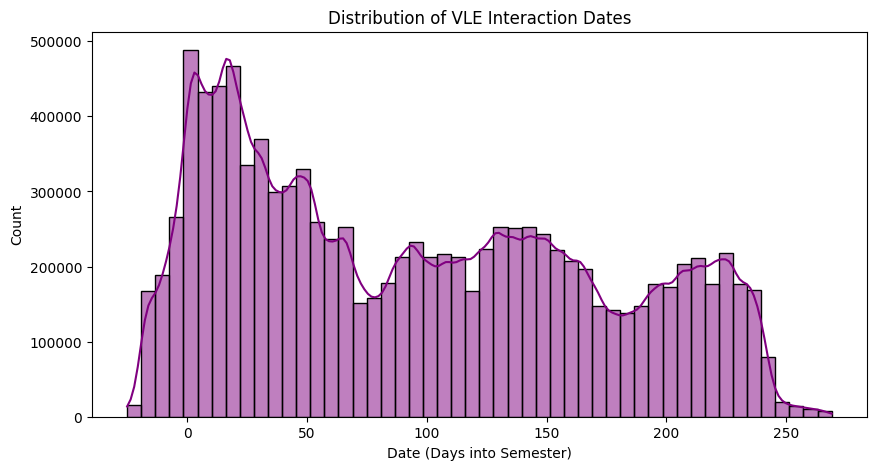

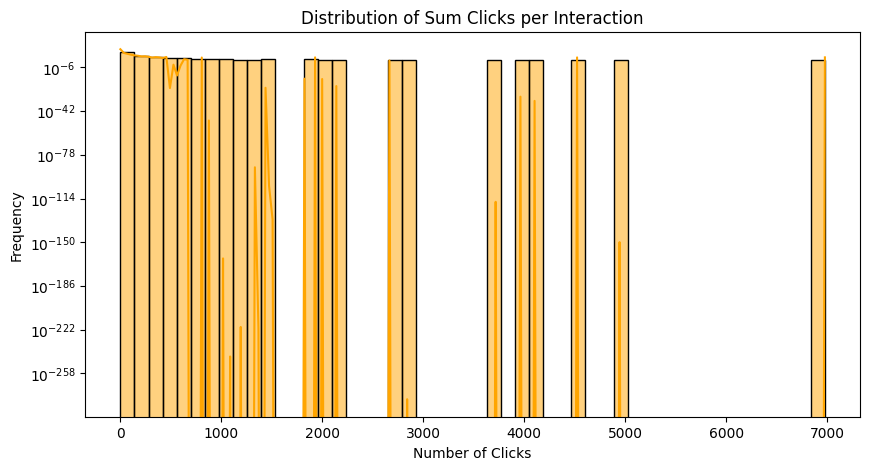

In [23]:
# EDA for student_vle data

print("--- Missing Values in student_vle ---")
print(student_vle.isnull().sum())

print("\n--- Value Counts for Categorical Features ---")
for col in ['code_module', 'code_presentation']:
    print(f"\n{col}:")
    print(student_vle[col].value_counts().head())

print("\n--- Unique Students and VLE Resources ---")
print(f"Number of unique students: {student_vle['id_student'].nunique()}")
print(f"Number of unique VLE resources (id_site): {student_vle['id_site'].nunique()}")

# Visualize distribution of interaction dates
plt.figure(figsize=(10, 5))
sns.histplot(student_vle['date'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of VLE Interaction Dates')
plt.xlabel('Date (Days into Semester)')
plt.ylabel('Count')
plt.show()

# Visualize distribution of sum_click
plt.figure(figsize=(10, 5))
sns.histplot(student_vle['sum_click'].dropna(), bins=50, kde=True, color='orange')
plt.title('Distribution of Sum Clicks per Interaction')
plt.xlabel('Number of Clicks')
plt.ylabel('Frequency')
plt.yscale('log') # Use log scale for better visualization of skewed data
plt.show()

In [ ]:
# how know the number of clicks whith assessment